<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
all_texts = (
    list(dataset['train']['text'])
    + list(dataset['test']['text'])
    + list(dataset['unsupervised']['text'])
)

for text in tqdm(all_texts, desc="Обработка текстов"):
    for sent in sent_tokenize(text):
        tokens = word_tokenize(sent.lower())
        if len(tokens) < word_threshold:
            sentences.append(sent.lower())

print("Всего предложений:", len(sentences))

Обработка текстов:   0%|          | 0/100000 [00:00<?, ?it/s]

Всего предложений: 786983


In [ ]:
# print("Всего предложений:", len(sentences))

In [ ]:
# токенизация
sentences_final = [word_tokenize(s) for s in tqdm(sentences)]

print("Всего токенов:", len(sentences_final))

  0%|          | 0/786983 [00:00<?, ?it/s]

Всего токенов: 786983


In [ ]:
# Последние пару предложений как есть
sentences[0:2]

['i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967.',
 "really, the sex and nudity scenes are few and far between, even then it's not shot like some cheaply made porno."]

In [ ]:
# Последние пару предложений как токены
sentences_final[0:2]

[['i',
  'rented',
  'i',
  'am',
  'curious-yellow',
  'from',
  'my',
  'video',
  'store',
  'because',
  'of',
  'all',
  'the',
  'controversy',
  'that',
  'surrounded',
  'it',
  'when',
  'it',
  'was',
  'first',
  'released',
  'in',
  '1967',
  '.'],
 ['really',
  ',',
  'the',
  'sex',
  'and',
  'nudity',
  'scenes',
  'are',
  'few',
  'and',
  'far',
  'between',
  ',',
  'even',
  'then',
  'it',
  "'s",
  'not',
  'shot',
  'like',
  'some',
  'cheaply',
  'made',
  'porno',
  '.']]

Посчитаем для каждого слова его встречаемость.

In [ ]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences_final):
    words.update(sentence)

print(f"Всего уникальных слов: {len(words)}")

  0%|          | 0/786983 [00:00<?, ?it/s]

Всего уникальных слов: 144407


In [ ]:
# Смотрим, что за словечки в топе
# words.most_common()[:5]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word in sorted(words, key=words.get, reverse=True)[:vocab_size]:
        vocab.add(word)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


In [ ]:
# print("Всего слов в словаре:", len(vocab))

### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
# word2ind = {char: i for i, char in enumerate(vocab)}
# ind2word = {i: char for char, i in word2ind.items()}
vocab_list = sorted(vocab)
word2ind = {word: i for i, word in enumerate(vocab_list)}
ind2word = {i: word for word, i in word2ind.items()}

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokens = self.data[idx] # уже токены
        tokenized_sentence = [self.bos_id] + [word2ind.get(word, self.unk_id) for word in tokens] + [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [ ]:
train_sentences, temp_sentences = train_test_split(sentences_final, test_size=0.2)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возможные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

Добавим ряд вспомогательных функций

In [ ]:
# Установка начального состояния ГСЧ
import random
import os
def make_seed(seed: int=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

In [ ]:
# Функция отрисовки
def plot_metrics(losses, perplexities_train, perplexities_eval):
    epochs = range(1, len(losses) + 1)

    plt.figure(figsize=(14,5))

    # График loss
    plt.subplot(1,2,1)
    plt.plot(epochs, losses, 'b-o', label='Training Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # График perplexity
    plt.subplot(1,2,2)
    plt.plot(epochs, perplexities_train, 'g-o', label='Train Perplexity')
    plt.plot(epochs, perplexities_eval, 'r-o', label='Eval Perplexity')
    plt.title('Perplexity over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.grid(True)
    plt.legend()

    plt.show()

In [ ]:
# Генерация текста
# temperature - креативность

import torch.nn.functional as F

def generate_text(model, start_text: str, max_len: int = 30, temperature: float = 1.0):
    model.eval()
    tokens = word_tokenize(start_text.lower())
    input_ids = torch.tensor([[word2ind.get(t, word2ind['<unk>']) for t in tokens]], device=device)

    for _ in range(max_len):
        with torch.no_grad():
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :] / temperature
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

        if ind2word[next_token] == '<eos>':
            break
        input_ids = torch.cat([input_ids, torch.tensor([[next_token]], device=device)], dim=1)

    generated_tokens = [ind2word[i.item()] for i in input_ids[0]]

    return " ".join(generated_tokens)

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [ ]:
# Напишите код здесь
def train_model(model, train_dataloader, eval_dataloader, num_epoch:int = 5):
    make_seed()

    losses = []
    perplexities_train = []
    perplexities_eval = []

    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch+1}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities_train.append(evaluate(model, criterion, train_dataloader))
        perplexities_eval.append(evaluate(model, criterion, eval_dataloader))

    return model, losses, perplexities_train, perplexities_eval

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [ ]:
# модель с GRU
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])

        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

Training epoch 1::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/4919 [00:00<?, ?it/s]

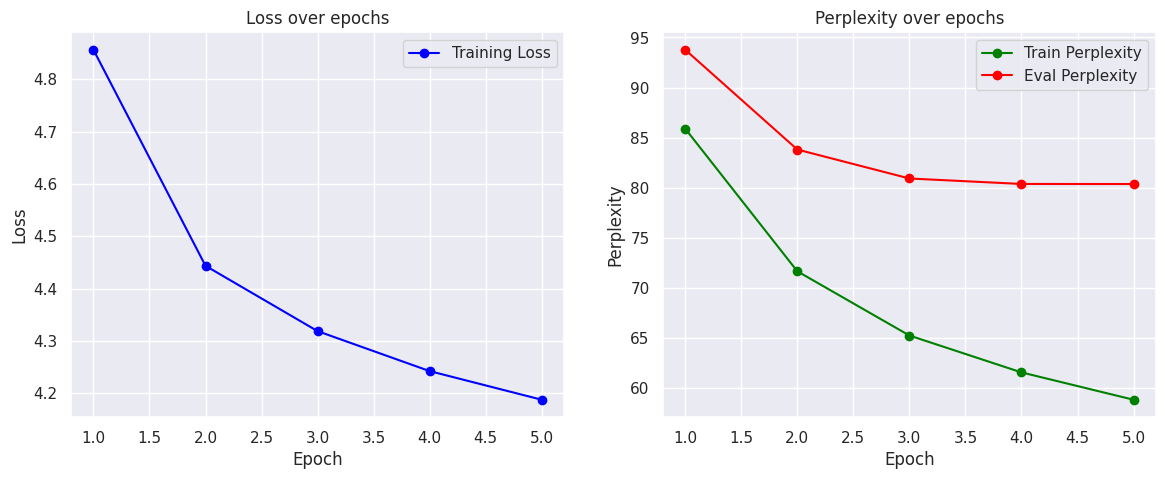

Test Perplexity: 80.16197776484296


In [ ]:
# Обучите модель здесь

# GRU 1
num_epoch = 5

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

model = LanguageModel(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_gru, losses_gru, ppl_train_gru, ppl_eval_gru = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_gru, ppl_train_gru, ppl_eval_gru)

# # #
test_ppl = evaluate(model_gru, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

In [ ]:
# Проверим возможность модели генерировать текст
print(generate_text(model_gru, start_text="Once upon a time", max_len=30))

once upon a time composing impossible twists barely really provide printing proceedings concentrated nothingness .


In [ ]:
# В целом текст получается продолжить, хотя конечно в смысловом плане он неочень хорош.

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [ ]:
# Проведите второй эксперимент

In [ ]:
# модели с LSTM
class LanguageModel_LSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.1 if num_layers > 1 else 0)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(output)  # Без лишнего tanh
        return projection

Training epoch 1::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/4919 [00:00<?, ?it/s]

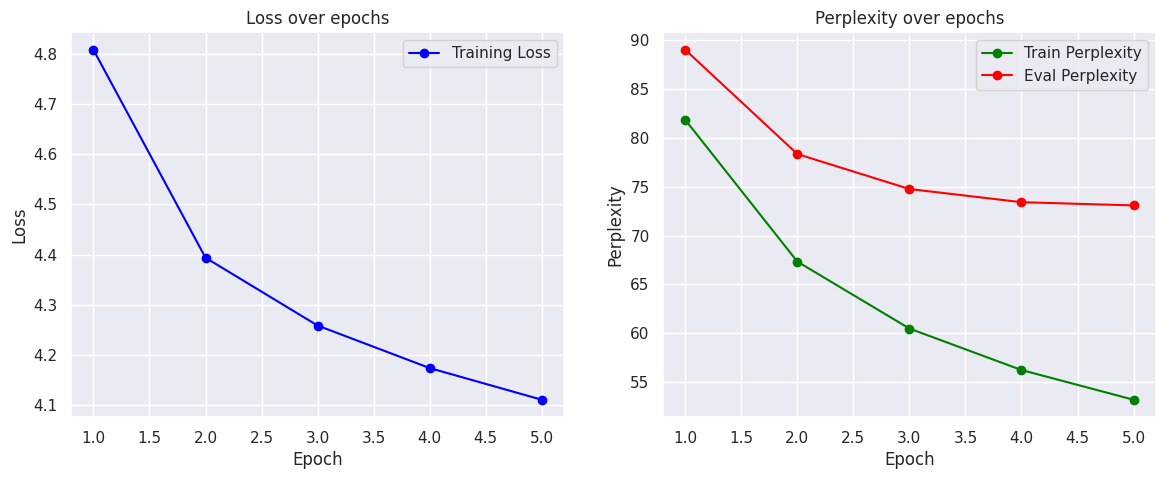

Test Perplexity: 73.24966002673638


In [ ]:
# LSTM 1
num_epoch = 5
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
model = LanguageModel_LSTM(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_lstm, losses_lstm, ppl_train_lstm, ppl_eval_lstm = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_lstm, ppl_train_lstm, ppl_eval_lstm)

# # #
test_ppl = evaluate(model_lstm, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

In [ ]:
# Проверим возможность модели генерировать текст

print(generate_text(model_lstm, start_text="Once upon a time", max_len=30))

once upon a time of the 1950 's so many years old to finish the film again .


In [ ]:
# В целом текст генерируется.
# Сравним результаты моделей GRU и LSTM

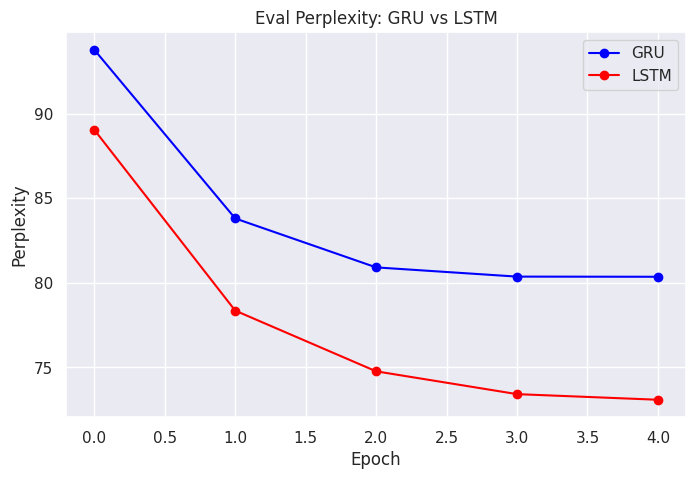

In [ ]:
# Сравним перплексии GRU и LSTM
plt.figure(figsize=(8,5))
plt.plot(ppl_eval_gru, 'b-o', label='GRU')
plt.plot(ppl_eval_lstm, 'r-o', label='LSTM')
plt.title('Eval Perplexity: GRU vs LSTM')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Сделаем сравнительную генерацию текстов
test_list = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list:
    print("Query:", query)

    response_gru = generate_text(model_gru, start_text=query, max_len=25)
    print("Response generator GRU:", response_gru)

    response_lstm = generate_text(model_lstm, start_text=query, max_len=25)
    print("Response generator LSTM:", response_lstm)

    print("-" * 50)

Query: this movie
Response generator GRU: this movie rested theatres suzanne freddie prochnow processor numb separately .
Response generator LSTM: this movie was filmed on it .
--------------------------------------------------
Query: the acting
Response generator GRU: the acting scales not quite sexy .
Response generator LSTM: the acting is totally different , added to the plot and simply unfunny this movie looks quite new .
--------------------------------------------------
Query: i would not recommend
Response generator GRU: i would not recommend that sort of poorly developed .
Response generator LSTM: i would not recommend this to anyone either like george clooney and i do n't spend it ?
--------------------------------------------------
Query: i really loved
Response generator GRU: i really loved this movie .
Response generator LSTM: i really loved hearing feelings about some of the situations and going to a fun .
--------------------------------------------------
Query: the plot


In [ ]:
# Обе мрдели генерируют текст, но (конечно субъективно) LSTM выполняет это чуть лучше(в среднем предложения длиннее и более связные).
# Сгенерироанные предложения обоих моделей оставляют желать лучшего.

In [ ]:
# Пробуем улучшить токенизацию - не токенизируем предложения из одних знаков пунктуцации, пустые строки и т.п. Ограничение по длине оставим прежнее - до 32 символов.

import string

sentences = []
word_threshold = 32
punctuation = set(string.punctuation)

all_texts = (
    list(dataset['train']['text'])
    + list(dataset['test']['text'])
    + list(dataset['unsupervised']['text'])
)

for text in tqdm(all_texts, desc="Обработка текстов"):
    for sent in sent_tokenize(text):
        tokens = word_tokenize(sent.lower())

        # фильтруем шум: пустые или только пунктуация
        if not tokens:
            continue
        if all(tok in punctuation for tok in tokens):
            continue

        # ограничение по длине
        if len(tokens) < word_threshold:
            sentences.append(sent.lower())

print("Всего предложений:", len(sentences))

Обработка текстов:   0%|          | 0/100000 [00:00<?, ?it/s]

Всего предложений: 781336


In [ ]:
sentences_final = [word_tokenize(s) for s in tqdm(sentences)]
print("Всего токенов:", len(sentences_final))

  0%|          | 0/781336 [00:00<?, ?it/s]

Всего токенов: 781336


In [ ]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences_final):
    words.update(sentence)

print(f"Всего уникальных слов: {len(words)}")

  0%|          | 0/781336 [00:00<?, ?it/s]

Всего уникальных слов: 144406


In [ ]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word in sorted(words, key=words.get, reverse=True)[:vocab_size]:
        vocab.add(word)

assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

print("Всего слов в словаре:", len(vocab))

# Далее выполняем блоки существующего пайплайна
# ....

Всего слов в словаре: 40004


Training epoch 1::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/4884 [00:00<?, ?it/s]

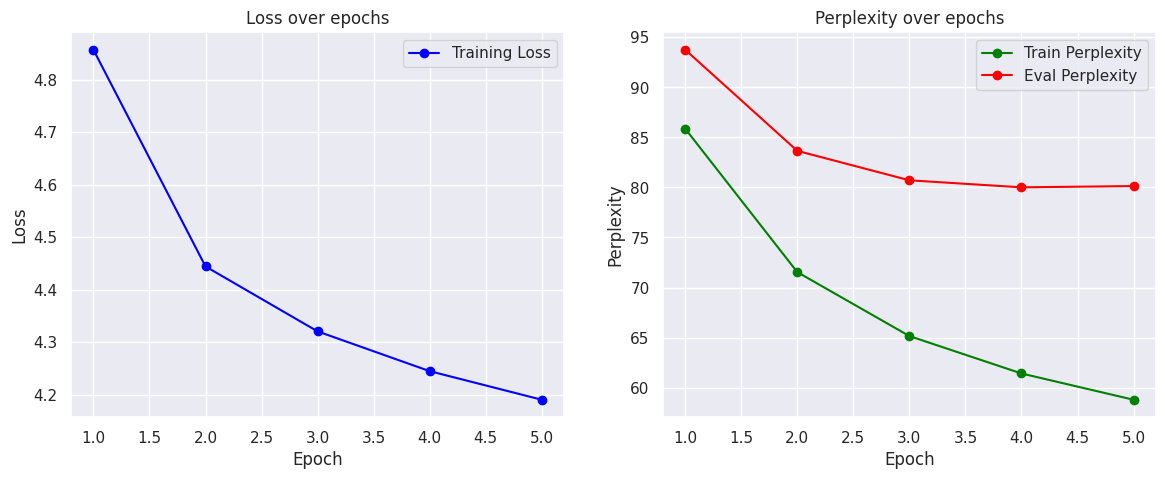

Test Perplexity: 80.21316550796433


In [ ]:
# GRU 2
num_epoch = 5
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
model = LanguageModel(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_gru, losses_gru, ppl_train_gru, ppl_eval_gru = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_gru, ppl_train_gru, ppl_eval_gru)

# # #
test_ppl = evaluate(model_gru, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

Training epoch 1::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/4884 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/4884 [00:00<?, ?it/s]

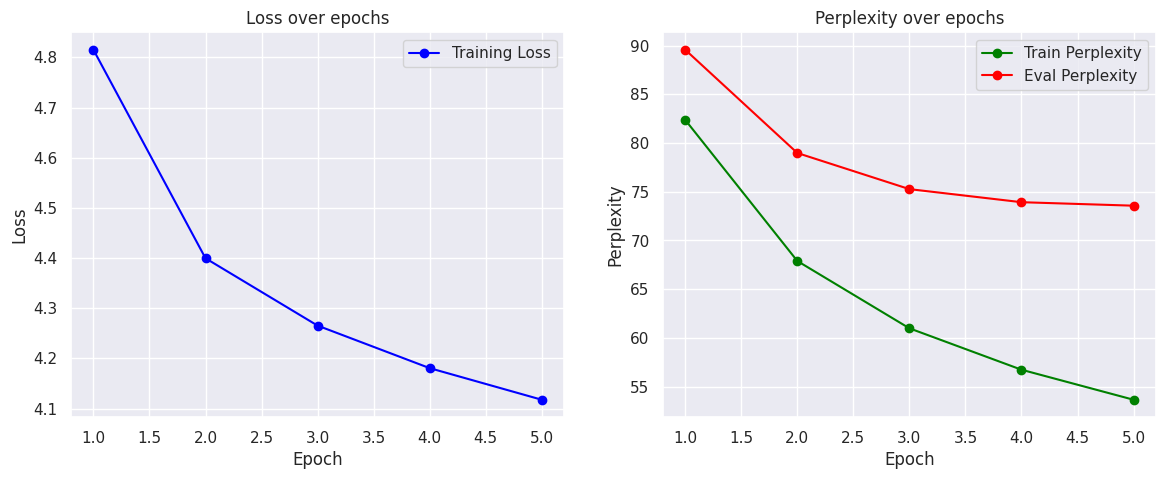

Test Perplexity: 73.6358876017619


In [ ]:
# LSTM 2
num_epoch = 5
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
model = LanguageModel_LSTM(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_lstm, losses_lstm, ppl_train_lstm, ppl_eval_lstm = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_lstm, ppl_train_lstm, ppl_eval_lstm)

# # #
test_ppl = evaluate(model_lstm, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

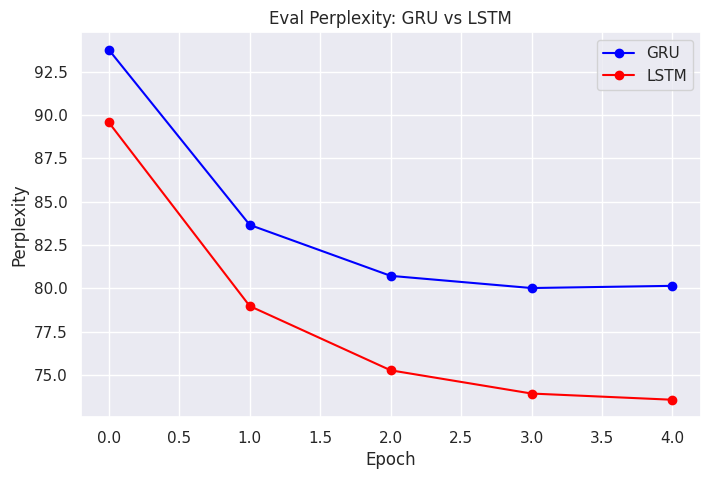

In [ ]:
# Сравним перплексии GRU 2 и LSTM 2
plt.figure(figsize=(8,5))
plt.plot(ppl_eval_gru, 'b-o', label='GRU')
plt.plot(ppl_eval_lstm, 'r-o', label='LSTM')
plt.title('Eval Perplexity: GRU vs LSTM')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Сделаем сравнительную генерацию текстов
test_list = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list:
    print("Query:", query)

    response_gru = generate_text(model_gru, start_text=query, max_len=25)
    print("Response generator GRU:", response_gru)

    response_lstm = generate_text(model_lstm, start_text=query, max_len=25)
    print("Response generator LSTM:", response_lstm)

    print("-" * 50)

Query: this movie
Response generator GRU: this movie come on. < br / > 6
Response generator LSTM: this movie is ?
--------------------------------------------------
Query: the acting
Response generator GRU: the acting rests on their face weaker , the 2005 scene .
Response generator LSTM: the acting stops fly in the first one .
--------------------------------------------------
Query: i would not recommend
Response generator GRU: i would not recommend this movie to anyone .
Response generator LSTM: i would not recommend watching this again , i have seen <unk> .
--------------------------------------------------
Query: i really loved
Response generator GRU: i really loved this movie and when it was advertised it gave me a little sense of anticipation .
Response generator LSTM: i really loved nana copycat `` this guy louise '' .
--------------------------------------------------
Query: the plot
Response generator GRU: the plot fell backs negated into h.k used fathom evokes a shotgun appre

In [ ]:
# Перплексия для обоих моделей стала чуть больше(хуже), хотя и незначительно.
# Пробуем изменить train_model + используем вариант токенизации как в предыдущем опыте
# Поскольку LSTM заметно лучше чем GRU, то для дальнейших опытов буду использовать только LSTM

In [ ]:
# Измененнная ф-я train_model(планировщик + другой оптимизатор + Gradient clipping)
def train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch: int = 5,
    lr: float = 3e-4,
    weight_decay: float = 1e-2
):
    make_seed()

    losses = []
    perplexities_train = []
    perplexities_eval = []

    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1
    )

    model.to(device)

    for epoch in range(num_epoch):
        model.train()
        epoch_losses = []

        loop = tqdm(train_dataloader, desc=f"Training epoch {epoch+1}/{num_epoch}")
        for batch in loop:
            optimizer.zero_grad()

            # Прямой проход
            logits = model(batch['input_ids'].to(device)).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].to(device).flatten())

            # Обратный проход
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())
            loop.set_postfix(loss=loss.item())


        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)

        ppl_train = evaluate(model, criterion, train_dataloader)
        ppl_eval = evaluate(model, criterion, eval_dataloader)

        perplexities_train.append(ppl_train)
        perplexities_eval.append(ppl_eval)

        # Обновляем scheduler
        scheduler.step(ppl_eval)
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"\nEpoch {epoch+1}/{num_epoch} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Train PPL: {ppl_train:.2f} | "
            f"Eval PPL: {ppl_eval:.2f} | "
            f"LR: {current_lr:.6f}"
        )

    return model, losses, perplexities_train, perplexities_eval

Training epoch 1/5:   0%|          | 0/4919 [00:00<?, ?it/s]


Epoch 1/5 | Train Loss: 5.0744 | Train PPL: 106.55 | Eval PPL: 110.94 | LR: 0.000300


Training epoch 2/5:   0%|          | 0/4919 [00:00<?, ?it/s]


Epoch 2/5 | Train Loss: 4.6023 | Train PPL: 86.07 | Eval PPL: 92.74 | LR: 0.000300


Training epoch 3/5:   0%|          | 0/4919 [00:00<?, ?it/s]


Epoch 3/5 | Train Loss: 4.4514 | Train PPL: 76.27 | Eval PPL: 84.73 | LR: 0.000300


Training epoch 4/5:   0%|          | 0/4919 [00:00<?, ?it/s]


Epoch 4/5 | Train Loss: 4.3572 | Train PPL: 70.22 | Eval PPL: 80.22 | LR: 0.000300


Training epoch 5/5:   0%|          | 0/4919 [00:00<?, ?it/s]


Epoch 5/5 | Train Loss: 4.2890 | Train PPL: 65.90 | Eval PPL: 77.30 | LR: 0.000300


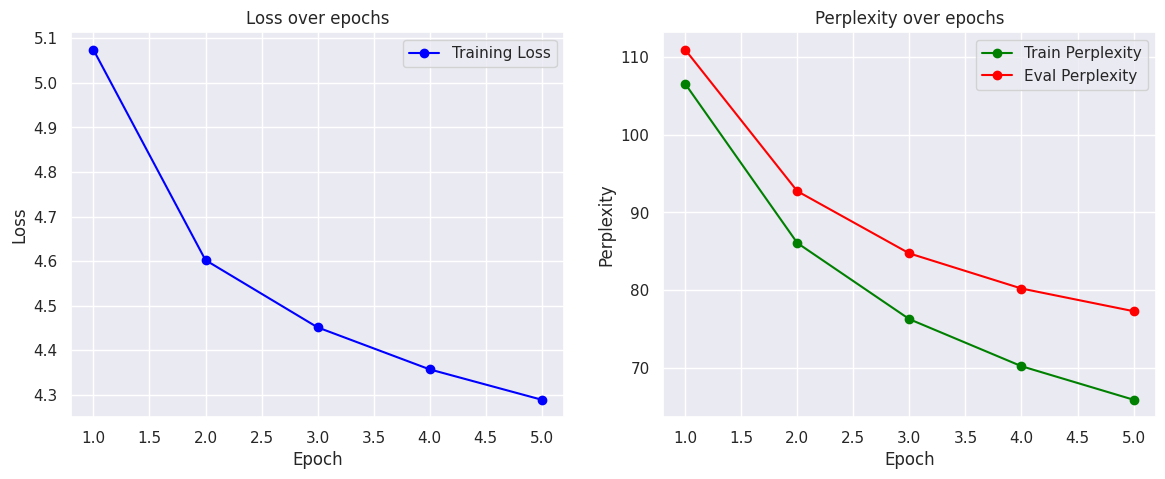

Test Perplexity: 77.91382033805537


In [ ]:
# LSTM 3
num_epoch = 5
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
model = LanguageModel_LSTM(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_lstm, losses_lstm, ppl_train_lstm, ppl_eval_lstm = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_lstm, ppl_train_lstm, ppl_eval_lstm)

# # #
test_ppl = evaluate(model_lstm, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

In [ ]:
# Проверим возможность модели генерировать текст
print(generate_text(model_lstm, start_text="Once upon a time", max_len=30))

once upon a time impossible time yours ! romero is n't going she must be remembered the conveniently .


In [ ]:
# Сделаем сравнительную генерацию текстов
test_list = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list:
    print("Query:", query)

    response_lstm = generate_text(model_lstm, start_text=query, max_len=25)
    print("Response generator LSTM:", response_lstm)

    print("-" * 50)

Query: this movie
Response generator LSTM: this movie must depict full name massive pieces puppet done acting and accurate characters royal sadism .
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting you separately effect in my mind actual offspring judge initial sense of the future .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend mullet helmer omega gang added crime patriot om failure nowadays funnier that. neill o chuck ' aag ... that sort of thing is the rest
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved genteel actions end another show random me and i do n't spend the only seven criticism of dicken .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot feelings calmed celebrates rawlins than bladerunner consistent nyu interaction letters

In [ ]:
# Что-то результат неочень.
# Попробуем LSTМ + train_model и токенизацию из первого опыта, но увеличим окно word_threshold до 40

In [ ]:
sentences = []
word_threshold = 40

# Получить отдельные предложения и поместить их в sentences
all_texts = (
    list(dataset['train']['text'])
    + list(dataset['test']['text'])
    + list(dataset['unsupervised']['text'])
)

for text in tqdm(all_texts, desc="Обработка текстов"):
    for sent in sent_tokenize(text):
        tokens = word_tokenize(sent.lower())
        if len(tokens) < word_threshold:
            sentences.append(sent.lower())

print("Всего предложений:", len(sentences))

Обработка текстов:   0%|          | 0/100000 [00:00<?, ?it/s]

Всего предложений: 887746


In [ ]:
# токенизация
sentences_final = [word_tokenize(s) for s in tqdm(sentences)]
print("Всего токенов:", len(sentences_final))

  0%|          | 0/887746 [00:00<?, ?it/s]

Всего токенов: 887746


In [ ]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences_final):
    words.update(sentence)

print(f"Всего уникальных слов: {len(words)}")

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word in sorted(words, key=words.get, reverse=True)[:vocab_size]:
        vocab.add(word)

assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

print("Всего слов в словаре:", len(vocab))

  0%|          | 0/887746 [00:00<?, ?it/s]

Всего уникальных слов: 167962
Всего слов в словаре: 40004


Training epoch 1::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/5549 [00:00<?, ?it/s]

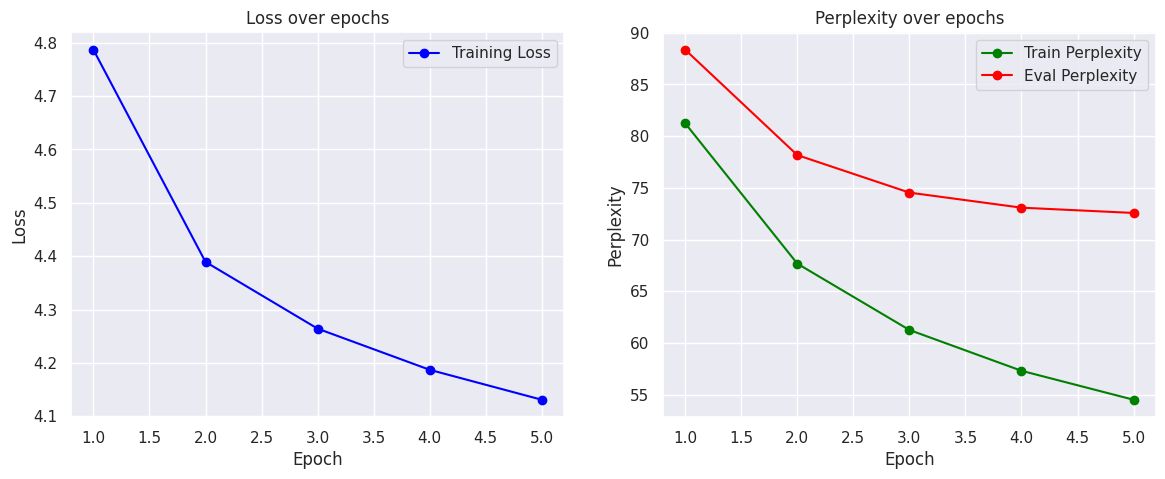

Test Perplexity: 72.187379424785


In [ ]:
# LSTM 4
num_epoch = 5
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
model = LanguageModel_LSTM(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_lstm, losses_lstm, ppl_train_lstm, ppl_eval_lstm = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_lstm, ppl_train_lstm, ppl_eval_lstm)

# # #
test_ppl = evaluate(model_lstm, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

In [ ]:
# Сделаем сравнительную генерацию текстов
test_list = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list:
    print("Query:", query)

    response_lstm = generate_text(model_lstm, start_text=query, max_len=25)
    print("Response generator LSTM:", response_lstm)

    print("-" * 50)

Query: this movie
Response generator LSTM: this movie was like strangled dead old rotten ideas , asshole ?
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting is malevolent fantastic and that is the movie all !
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend these characters are on this one .
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved if you were watching in the tv game , december <unk> .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot also was the terrorists that they never forgot the <unk> of the titanic that they do n't come across as regular victims .
--------------------------------------------------


In [ ]:
# Результат есть, это пока лучший результат. Попробуем прогнать на 10-ти эпохах.

Training epoch 1::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/5549 [00:00<?, ?it/s]

Training epoch 10::   0%|          | 0/5549 [00:00<?, ?it/s]

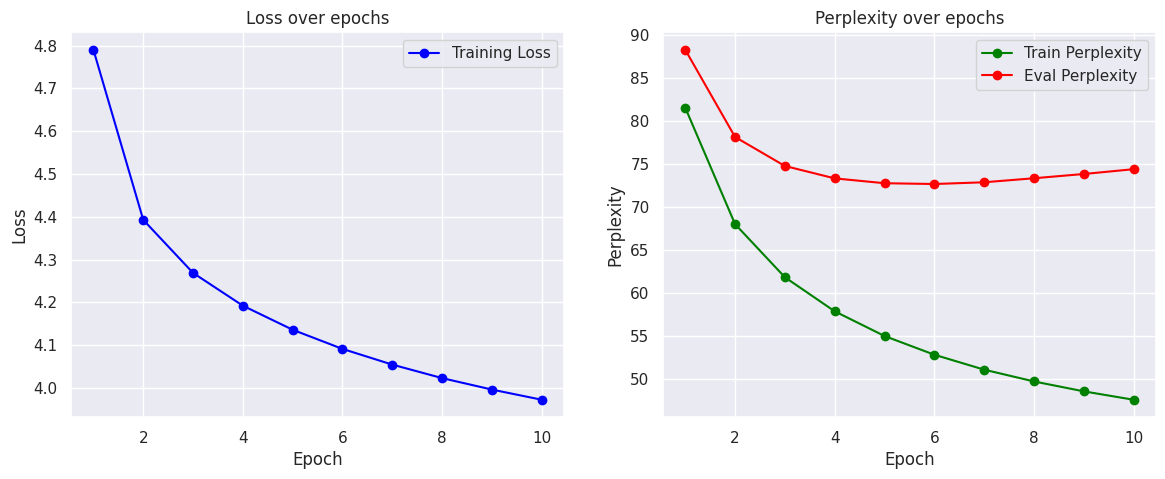

Test Perplexity: 74.37709437873247


In [ ]:
# LSTM 5
num_epoch = 10

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

model = LanguageModel_LSTM(hidden_dim = 256, vocab_size = len(vocab)).to(device)
model_lstm, losses_lstm, ppl_train_lstm, ppl_eval_lstm = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epoch
)

# # #
plot_metrics(losses_lstm, ppl_train_lstm, ppl_eval_lstm)

# # #
test_ppl = evaluate(model_lstm, criterion, test_dataloader);
print(f"Test Perplexity: {test_ppl}")

In [ ]:
# Проверим возможность модели генерировать текст
# print(generate_text(model_lstm, start_text="Once upon a time", max_len=30))
print(generate_text(model_lstm, start_text="Once upon a time", max_len=30, temperature=1.5))

once upon a time gatherings peeking develop much stronger preconceived backup fake villain depicted traditional kashmir open his assets - cinematography <unk> < br / > < br / > 80 minute extras it


In [ ]:
# Сделаем сравнительную генерацию текстов
test_list = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list:
    print("Query:", query)

    response_lstm = generate_text(model_lstm, start_text=query, max_len=25)
    print("Response generator LSTM:", response_lstm)

    print("-" * 50)

Query: this movie
Response generator LSTM: this movie is based on what ?
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting is superb .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend that batman sucked , hopefully , and .
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved ?
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot <unk> .
--------------------------------------------------


In [ ]:
# Новый эксперимент
#
# Единый пайплайн на основе блоков выше.
# Единый пайплайн удобнее запускать, т.к. при завершении квот в Колабе приходится возвращаться к работе лишь несколько дней. И для того, чтобы не забывать сделанные изменения и планируемые шаги нового пайплайна,
# я его(пайплан) заготовил заранее(в день, когда закончилась квота).
# Изменения в текущем пайплайне:
# * смотри класс LanguageModel_ImprovedLSTM
# * блок с обучением и запуском модели LanguageModel_ImprovedLSTM.

In [ ]:
# # # # # # # # # # # # # # # # # # # # # # #
!pip install datasets

# # # # # # # # # # # # # # # # # # # # # # #
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

nltk.download('punkt')
nltk.download('punkt_tab')

# # # # # # # # # # # # # # # # # # # # # # #
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

# # # # # # # # # # # # # # # # # # # # # # #

# Загрузим датасет
dataset = load_dataset('imdb')

# # # # # # # # # # # # # # # # # # # # # # #
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
all_texts = (
    list(dataset['train']['text'])
    + list(dataset['test']['text'])
    + list(dataset['unsupervised']['text'])
)

for text in tqdm(all_texts, desc="Обработка текстов"):
    for sent in sent_tokenize(text):
        tokens = word_tokenize(sent.lower())
        if len(tokens) < word_threshold:
            sentences.append(sent.lower())

print("Всего предложений:", len(sentences))


# токенизация
sentences_final = [word_tokenize(s) for s in tqdm(sentences)]
print("Всего токенов:", len(sentences_final))

# # # # # # # # # # # # # # # # # # # # # # #
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences_final):
    words.update(sentence)

print(f"Всего уникальных слов: {len(words)}")

# # # # # # # # # # # # # # # # # # # # # # #
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word in sorted(words, key=words.get, reverse=True)[:vocab_size]:
        vocab.add(word)

assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

print("Всего слов в словаре:", len(vocab))

# # # # # # # # # # # # # # # # # # # # # # #
vocab_list = sorted(vocab)
word2ind = {word: i for i, word in enumerate(vocab_list)}
ind2word = {i: word for word, i in word2ind.items()}

class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokens = self.data[idx] # уже токены
        tokenized_sentence = [self.bos_id] + [word2ind.get(word, self.unk_id) for word in tokens] + [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

# # # # # # # # # # # # # # # # # # # # # # #
train_sentences, temp_sentences = train_test_split(sentences_final, test_size=0.2)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

# # # # # # # # # # # # # # # # # # # # # # #
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

# Установка начального состояния ГСЧ
import random
import os
def make_seed(seed: int=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

# Функция отрисовки
def plot_metrics(losses, perplexities_train, perplexities_eval):
    epochs = range(1, len(losses) + 1)

    plt.figure(figsize=(14,5))

    # График loss
    plt.subplot(1,2,1)
    plt.plot(epochs, losses, 'b-o', label='Training Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # График perplexity
    plt.subplot(1,2,2)
    plt.plot(epochs, perplexities_train, 'g-o', label='Train Perplexity')
    plt.plot(epochs, perplexities_eval, 'r-o', label='Eval Perplexity')
    plt.title('Perplexity over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.grid(True)
    plt.legend()

    plt.show()


# Генерация текста
# temperature - креативность
import torch.nn.functional as F

def generate_text(model, start_text: str, max_len: int = 30, temperature: float = 1.0):
    model.eval()
    tokens = word_tokenize(start_text.lower())
    input_ids = torch.tensor([[word2ind.get(t, word2ind['<unk>']) for t in tokens]], device=device)

    for _ in range(max_len):
        with torch.no_grad():
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :] / temperature
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

        if ind2word[next_token] == '<eos>':
            break
        input_ids = torch.cat([input_ids, torch.tensor([[next_token]], device=device)], dim=1)

    generated_tokens = [ind2word[i.item()] for i in input_ids[0]]

    return " ".join(generated_tokens)

# # # # # # # # # # # # # # # # # # # # # # #
def train_model(model, train_dataloader, eval_dataloader, num_epoch:int = 5):
    make_seed()

    losses = []
    perplexities_train = []
    perplexities_eval = []

    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch+1}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities_train.append(evaluate(model, criterion, train_dataloader))
        perplexities_eval.append(evaluate(model, criterion, eval_dataloader))

    return model, losses, perplexities_train, perplexities_eval


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Всего предложений: 786983


  0%|          | 0/786983 [00:00<?, ?it/s]

Всего токенов: 786983


  0%|          | 0/786983 [00:00<?, ?it/s]

Всего уникальных слов: 144407
Всего слов в словаре: 40004


Training epoch 1::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/4919 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/4919 [00:00<?, ?it/s]

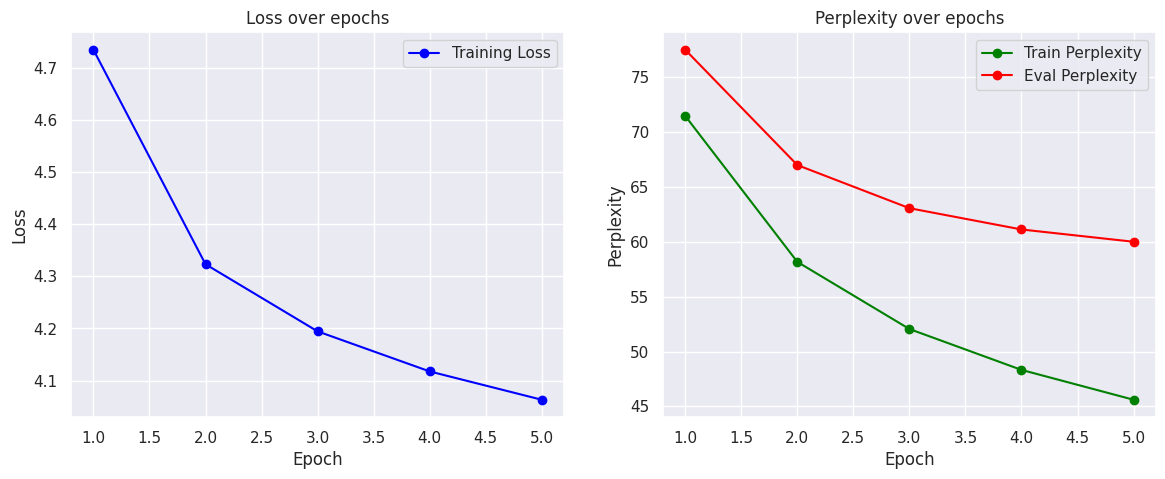

NameError: name 'criterion' is not defined

In [ ]:
# # # # # # # # # # # # # # # # # # # # # # #
# модель с LSTM 6
class LanguageModel_ImprovedLSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout_layer = nn.Dropout(p=dropout)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout_layer(self.linear(self.non_lin(output)))
        projection = self.projection(output)
        return projection

# # # # # # # # # # # # # # # # # # # # # # #
# LSTM 6
num_epoch_improved = 5
hidden_dim_improved = 512 # было 256
num_layers_improved = 2 # ещё один слой
dropout_improved = 0.3 #  был 0.1

model_improved = LanguageModel_ImprovedLSTM(
    hidden_dim = hidden_dim_improved,
    vocab_size = len(vocab),
    num_layers = num_layers_improved,
    dropout = dropout_improved
).to(device)

model_improved, losses_improved, ppl_train_improved, ppl_eval_improved = train_model(
    model_improved,
    train_dataloader,
    eval_dataloader,
    num_epoch=num_epoch_improved
)

# # #
plot_metrics(losses_improved, ppl_train_improved, ppl_eval_improved)

# # #
test_ppl_improved = evaluate(model_improved, criterion, test_dataloader)
print(f"Test Perplexity (Improved Model): {test_ppl_improved}")

# # # # # # # # # # # # # # # # # # # # # # #
# Генерация текста
test_list_improved = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list_improved:
    print("Query:", query)
    response_improved = generate_text(model_improved, start_text=query, max_len=25)
    print("Response (Improved Model):", response_improved)
    print("-" * 50)

In [ ]:
# Исправил ошибку "NameError: name 'criterion' is not defined". В остальном всё хорошо, модель обучилась.

# # #
# plot_metrics(losses_improved, ppl_train_improved, ppl_eval_improved)

# # #
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
test_ppl_improved = evaluate(model_improved, criterion, test_dataloader)
print(f"Test Perplexity (Improved Model): {test_ppl_improved}")

# # # # # # # # # # # # # # # # # # # # # # #
# Генерация текста
test_list_improved = [
    "this movie",
    "the acting",
    "i would not recommend",
    "i really loved",
    "the plot"
]

for query in test_list_improved:
    print("Query:", query)
    response_improved = generate_text(model_improved, start_text=query, max_len=25)
    print("Response (Improved Model):", response_improved)
    print("-" * 50)

Test Perplexity (Improved Model): 60.145532660755684
Query: this movie
Response (Improved Model): this movie mainly pulls off .
--------------------------------------------------
Query: the acting
Response (Improved Model): the acting of olivia mcdermott as pooja was good , and none of her backstory was believable .
--------------------------------------------------
Query: i would not recommend
Response (Improved Model): i would not recommend watching .
--------------------------------------------------
Query: i really loved
Response (Improved Model): i really loved .
--------------------------------------------------
Query: the plot
Response (Improved Model): the plot of the film is silly .
--------------------------------------------------


In [ ]:
# Более креативные текстовки
for query in test_list_improved:
    print("Query:", query)
    response_improved = generate_text(model_improved, start_text=query, max_len=25, temperature=1.7)
    print("Response (Improved Model):", response_improved)
    print("-" * 50)

Query: this movie
Response (Improved Model): this movie as unfortunate it marin end crenna would no further resolve and bakery humping so affect vh1 entertainingly moved thousands .
--------------------------------------------------
Query: the acting
Response (Improved Model): the acting masterpiece companion korvo chip .
--------------------------------------------------
Query: i would not recommend
Response (Improved Model): i would not recommend wholeheartedly brennan tone liza soon since bibleman mann .
--------------------------------------------------
Query: i really loved
Response (Improved Model): i really loved smart debates sedan history approved students once little offal craze rashomon dozes grown up 60 <unk>  redeeming cheese buds .
--------------------------------------------------
Query: the plot
Response (Improved Model): the plot continued that life top criticism hollywood introduces marple unfolds proceeds scribbles potboilers cousin miles from probed several older e

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

# РЕЗУЛЬТАТЫ ОПЫТОВ
*(красиво представить в табличном виде к сожалению не получилось)*

---

**№ опыта:** 1

**Ид опыта:** GRU 1

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Со знаками препинания, длиной до 32 символов
	* train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 5

**Модель:** LanguageModel с GRU

**Loss:**  Монотонно опускается к уровню ~4.2

**Test(Eval) Perplexity:** 80.161977764843

Пример генерации:

```
Query: this movie
Response generator GRU: this movie rested theatres suzanne freddie prochnow processor numb separately .
--------------------------------------------------
Query: the acting
Response generator GRU: the acting scales not quite sexy .
--------------------------------------------------
Query: i would not recommend
Response generator GRU: i would not recommend that sort of poorly developed .
--------------------------------------------------
Query: i really loved
Response generator GRU: i really loved this movie .
--------------------------------------------------
Query: the plot
Response generator GRU: the plot .
--------------------------------------------------
```

---

**№ опыта:** 2

**Ид опыта:** LSTM 1

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Со знаками препинания, длиной до 32 символов
	* train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 5

**Модель:** LanguageModel с LSTM

**Loss:**  Монотонно опускается к уровню ~4.1

**Test(Eval) Perplexity:** 73.2496600267364

Пример генерации:

```
Query: this movie
Response generator LSTM: this movie was filmed on it .
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting is totally different , added to the plot and simply unfunny this movie looks quite new .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend this to anyone either like george clooney and i do n't spend it ?
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved hearing feelings about some of the situations and going to a fun .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot devices of that ignored .
--------------------------------------------------
```

---

**№ опыта:** 3

**Ид опыта:** GRU 2

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Без знаков препинания, длиной до 32 символов

  * train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 5

**Модель:** LanguageModel с GRU

**Loss:**  Монотонно опускается к уровню ~4.2

**Test(Eval) Perplexity:** 80.2131655079643

Пример генерации:

```
Query: this movie
Response generator GRU: this movie come on. < br / > 6
--------------------------------------------------
Query: the acting
Response generator GRU: the acting rests on their face weaker , the 2005 scene .
--------------------------------------------------
Query: i would not recommend
Response generator GRU: i would not recommend this movie to anyone .
--------------------------------------------------
Query: i really loved
Response generator GRU: i really loved this movie and when it was advertised it gave me a little sense of anticipation .
--------------------------------------------------
Query: the plot
Response generator GRU: the plot fell backs negated into h.k used fathom evokes a shotgun apprentice to vermont the entire length of 2001 .
--------------------------------------------------
```



---

**№ опыта:** 4

**Ид опыта:** LSTM 2

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Без знаков препинания, длиной до 32 символов

  * train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 5

**Модель:** LanguageModel с LSTM

**Loss:**  Монотонно опускается к уровню ~4.1

**Test(Eval) Perplexity:** 73.6358876017619

Пример генерации:

```
Query: this movie
Response generator LSTM: this movie is ?
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting stops fly in the first one .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend watching this again , i have seen <unk> .
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved nana copycat `` this guy louise '' .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot outrageous : not people who made my look ?
--------------------------------------------------
```


---

**№ опыта:** 5

**Ид опыта:** LSTM 3

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Без знаков препинания, длиной до 32 символов

  * Оптимизатор AdamW + Gradient clipping

**Эпох обучения:** 5

**Модель:** LanguageModel с LSTM

**Loss:**  Монотонно опускается к уровню ~4.3

**Test(Eval) Perplexity:** 77.9138203380554

Пример генерации:

```
Query: this movie
Response generator LSTM: this movie must depict full name massive pieces puppet done acting and accurate characters royal sadism .
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting you separately effect in my mind actual offspring judge initial sense of the future .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend mullet helmer omega gang added crime patriot om failure nowadays funnier that. neill o chuck ' aag ... that sort of thing is the rest
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved genteel actions end another show random me and i do n't spend the only seven criticism of dicken .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot feelings calmed celebrates rawlins than bladerunner consistent nyu interaction letters desperately + gregg .
```


---

**№ опыта:** 6

**Ид опыта:** LSTM 4

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Со знаками препинания, длиной до 40 символов

  * train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 5

**Модель:** LanguageModel с LSTM

**Loss:**  Монотонно опускается к уровню ~4.12

**Test(Eval) Perplexity:** 72.187379424785

Пример генерации:

```
Query: this movie
Response generator LSTM: this movie was like strangled dead old rotten ideas , asshole ?
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting is malevolent fantastic and that is the movie all !
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend these characters are on this one .
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved if you were watching in the tv game , december <unk> .
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot also was the terrorists that they never forgot the <unk> of the titanic that they do n't come across as regular victims .
```


---

**№ опыта:** 7

**Ид опыта:** LSTM 5

**Особенности подготовки данных, модели и ф-ии обучения:**

	* Со знаками препинания, длиной до 40 символов

  * train_model – стандартный(оптимизатор Adam)

**Эпох обучения:** 10

**Модель:** LanguageModel с LSTM

**Loss:**  Монотонно опускается к уровню ~3.8

**Test(Eval) Perplexity:** 74.3770943787325

**Комментарий:** Примерно до 5-6 эпохи графики перплексии и лосса повторяют графики LSTM 4, но далее начинается рост перплексии, что свидетельствует о начале переобучения. На следующих 6-10 эпохах это лишь подтверждается(PP возрастает до ~74.4)


Пример генерации:

```
Query: this movie
Response generator LSTM: this movie is based on what ?
--------------------------------------------------
Query: the acting
Response generator LSTM: the acting is superb .
--------------------------------------------------
Query: i would not recommend
Response generator LSTM: i would not recommend that batman sucked , hopefully , and .
--------------------------------------------------
Query: i really loved
Response generator LSTM: i really loved ?
--------------------------------------------------
Query: the plot
Response generator LSTM: the plot <unk> .
```


---

**№ опыта:** 8

**Ид опыта:** LSTM 6

**Особенности подготовки данных, модели и ф-ии обучения:**

  * Со знаками препинания, длиной до 32 символов

  * Размер скрытого слоя увеличен до 512 (число нейронов в состоянии LSTM). В предыдущих опытах было по 256

  * Добавлен второй слой LSTM (до этого был только 1)

  * Увеличен dropout до 0.3 (до этого было 0.1)

**Эпох обучения:** 5

**Модель:** LanguageModel_ImprovedLSTM (тоже с LSTM, но решил переименовать)

**Loss:**  Монотонно опускается к уровню ~4.06

**Test(Eval) Perplexity:** 60.1455326607557

Пример генерации:

```
Query: this movie
Response (Improved Model): this movie mainly pulls off .
--------------------------------------------------
Query: the acting
Response (Improved Model): the acting of olivia mcdermott as pooja was good , and none of her backstory was believable .
--------------------------------------------------
Query: i would not recommend
Response (Improved Model): i would not recommend watching .
--------------------------------------------------
Query: i really loved
Response (Improved Model): i really loved .
--------------------------------------------------
Query: the plot
Response (Improved Model): the plot of the film is silly .
--------------------------------------------------


# Более креативно (температура = 1.7)

Query: this movie
Response (Improved Model): this movie as unfortunate it marin end crenna would no further resolve and bakery humping so affect vh1 entertainingly moved thousands .
--------------------------------------------------
Query: the acting
Response (Improved Model): the acting masterpiece companion korvo chip .
--------------------------------------------------
Query: i would not recommend
Response (Improved Model): i would not recommend wholeheartedly brennan tone liza soon since bibleman mann .
--------------------------------------------------
Query: i really loved
Response (Improved Model): i really loved smart debates sedan history approved students once little offal craze rashomon dozes grown up 60 <unk>  redeeming cheese buds .
--------------------------------------------------
Query: the plot
Response (Improved Model): the plot continued that life top criticism hollywood introduces marple unfolds proceeds scribbles potboilers cousin miles from probed several older environmentalists runaway around deciding which unit those
--------------------------------------------------
```

# Выводы:

В опытах №1 и №2 попробовал использовать модели с GRU и LSTM соответственно. При этом не ограничивал  по минимальной длине слова. Получил на 5 эпохах pp(1)=80,16 и pp(2)=73,125.

Далее в опытах №3 и №4 решил проверить гипотезу о том, что не нужно токенизировать однобуквенные символы, пустые строки, строки только из знаков препинания и т.п. Так же выполнил прогон GRU(опыт 3) и LSTM(опыт 4). Получил на 5 эпохах pp(3)=80,21 и pp(4)=73,64.

Поскольку на этих опытах модель с LSTM показала себя получше, то далее я решил экспериментировать без GRU.

Следующая гипотеза - попробовать другой оптимизатор(AdamW вместо Adam) и применить Gradient clipping. Получил на 5 эпохах pp(5)=77,91.

Результат опыта №5 мне показался сомнительным и я решил к изначальному способу подготовки токенов, т.е. убрал ограничение на минимальную длину токена, но увеличил токена с <32 до <40 символов. В результате, в опыте №6 получил на 5 эпохах pp(6)=72,18.

Поскольку pp(6) предыдущего опыта №6 была наименьшей, то я решил проверить гипотезу об увеличении количества эпох и в опыте №7 использовал тот же пайплайн(из опыта №6), но вдвое(до 10) увеличил число эпох.  Получил pp(7)=73,38. При этом, примерно до 5-6 эпохи графики перплексии и лосса повторяют графики LSTM 4(опыта №6), но далее начинается рост перплексии, что свидетельствует о начале переобучения. На следующих 6-10 эпохах это лишь подтверждается(PP возрастает до ~75).

Предыдущий опыт №7 показал, что нужно менять направление поисков, поэтому я решил внести сразу несколько корректив в пайплайн:
1-увеличил размер скрытого слоя до 512 (число нейронов в состоянии LSTM) вместо 256, как во всех предыдущих опытах; 2- добавил второй слой LSTM (до этого был только 1); 3-увеличел dropout до 0.3 (до этого было 0.1). Число эпох вернул до 5(т.к. 10 это затратно по времени и квотам Колаб).  Получил на 5 эпохах pp(8)=60,15.

На этом решил остановиться.

Отмечу, что:

* loss во всех опытах демонстрировал монотонное снижение, даже при переобучении модели в опыте №7.
* После каждого опыта я проводил тестовую генерацию нескольких предложений с одинаковой затравкой(при "температуре" = 1, т.е. без особенного креатива), но во всех случаях смысла(и связности) в полученных предложениях было не много(причем чем длиннее предложение, тем смысла-связности меньше).  

---

# Гипотезы для дальнейшего улучшения моделей

* Изменить(увеличить) р-р скрытого слоя hidden_dim
* Изменить(увеличить) количество слоев num_layers
* Изменить dropout
* Использовать другие ф-ии активации и "поиграться" с их параметрами
* Поизменять параметры learning_rate и scheduler
* Увеличить число эпох обучения
* Изменить размер бача
* Попробовать разные оптимизаторы
* Попробовать другие способы токенизации
* Добавить механизм внимания(Attention mechanism)

